# ============================================================
# Notebook: 02_rfm_analysis.ipynb
# ============================================================

### =========================
### 1. IMPORT LIBRARIES
### =========================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# For visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

### =========================
### 2. LOAD CLEANED DATA
### =========================

In [2]:
df = pd.read_csv('../data/processed/cleaned_transactions.csv', parse_dates=['invoicedate'])
print("✅ Data loaded successfully")

✅ Data loaded successfully


In [3]:
print(f"Shape: {df.shape}")
print(f"Date range: {df['invoicedate'].min()} to {df['invoicedate'].max()}")
print(f"Total customers: {df['customer_id'].nunique():,}")
print(f"Total transactions: {len(df):,}")
print(f"Total revenue: ${df['total_price'].sum():,.2f}")

Shape: (779425, 16)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Total customers: 5,878
Total transactions: 779,425
Total revenue: $17,374,804.27


In [4]:
# Display first few rows
df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,total_price,year,month,month_name,day,hour,day_of_week,year_month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,December,1,7,Tuesday,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,December,1,7,Tuesday,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,December,1,7,Tuesday,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,December,1,7,Tuesday,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,December,1,7,Tuesday,2009-12


### =========================
### 3. RFM METRICS CALCULATION
### =========================

In [5]:
reference_date = df['invoicedate'].max() + timedelta(days=1)

In [6]:
rfm = df.groupby('customer_id').agg({
    'invoicedate': lambda x: (reference_date - x.max()).days,  # Recency
    'invoice': 'nunique',  # Frequency 
    'total_price': 'sum'   # Monetary
}).reset_index()

In [7]:
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']


In [8]:
print(f"\n📊 RFM Metrics Summary:")
print(f"Total customers in RFM analysis: {len(rfm):,}")


📊 RFM Metrics Summary:
Total customers in RFM analysis: 5,878


In [9]:
# Check for any customers with zero monetary value 
print(f"Customers with zero monetary value: {(rfm['monetary'] == 0).sum()}")

Customers with zero monetary value: 0


In [10]:
# Display basic statistics
print("\n📈 RFM Descriptive Statistics:")
rfm[['recency', 'frequency', 'monetary']].describe()


📈 RFM Descriptive Statistics:


,recency,frequency,monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


### =========================
### 4. RFM SCORING SYSTEM
### =========================

In [11]:
rfm['r_score'] = pd.qcut(rfm['recency'], q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['rfm_score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)
rfm['rfm_total'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']


### =========================
### 5. CUSTOMER SEGMENTATION
### =========================

In [12]:
def segment_customers(row):
    """
    Segment customers based on RFM scores using standard marketing segmentation
    """
    r = row['r_score']
    f = row['f_score']
    m = row['m_score']
    
    # Champions: Best customers - bought recently, often, and spent the most
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    
    # Loyal Customers: Good frequency and monetary, but maybe not the most recent
    elif r >= 2 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    
    # Potential Loyalists: Recent and frequent, but lower spend
    elif r >= 3 and f >= 2 and m == 2:
        return 'Potential Loyalists'
    
    # New Customers: Recent purchase but low frequency
    elif r >= 3 and f == 1:
        return 'New Customers'
    
    # Promising: Recent and moderate spend
    elif r >= 3 and f == 2 and m == 1:
        return 'Promising'
    
    # Need Attention: Not so recent, average spend
    elif r == 2 and f <= 2 and m <= 2:
        return 'Need Attention'
    
    # About to Sleep: Haven't purchased in a while, average spend
    elif r == 2 and f <= 1:
        return 'About to Sleep'
    
    # At Risk: Haven't purchased in a long time, but used to be good
    elif r == 1 and f >= 2:
        return 'At Risk'
    
    # Cannot Lose Them: Used to purchase frequently but not recently
    elif r == 1 and f >= 3:
        return 'Cannot Lose Them'
    
    # Hibernating: Low recency, low frequency, low monetary
    elif r == 1 and f == 1 and m == 1:
        return 'Hibernating'
    
    # Lost: Worst customers
    elif r == 1 and f == 1 and m <= 2:
        return 'Lost'
    
    else:
        return 'Other'


In [13]:
rfm['customer_segment'] = rfm.apply(segment_customers, axis=1)

In [14]:
# Display segment distribution
print("\n📊 Customer Segment Distribution:")
segment_counts = rfm['customer_segment'].value_counts()
segment_percentages = (segment_counts / len(rfm) * 100).round(2)
segment_summary = pd.DataFrame({
    'count': segment_counts,
    'percentage': segment_percentages
})
print(segment_summary)


📊 Customer Segment Distribution:
                     count  percentage
customer_segment                      
Champions             1821       30.98
At Risk                687       11.69
Need Attention         677       11.52
Hibernating            571        9.71
Other                  517        8.80
Loyal Customers        488        8.30
Potential Loyalists    483        8.22
New Customers          336        5.72
Lost                   161        2.74
Promising              110        1.87
About to Sleep          27        0.46


### =========================
### 6. SEGMENT-LEVEL KPIs
### =========================

In [15]:
# Calculate KPIs per segment
segment_kpis = rfm.groupby('customer_segment').agg(
    customer_count=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2).reset_index()

In [16]:
# Calculate revenue percentage
segment_kpis['revenue_percentage'] = (segment_kpis['total_revenue'] / segment_kpis['total_revenue'].sum() * 100).round(2)

# Sort by revenue
segment_kpis = segment_kpis.sort_values('total_revenue', ascending=False)

print("\n💰 Segment-Level KPIs:")
display(segment_kpis)


💰 Segment-Level KPIs:


,customer_segment,customer_count,avg_recency,avg_frequency,avg_monetary,total_revenue,revenue_percentage
2,Champions,1821,29.30,14.07,7241.26,13186331.03,75.89
5,Loyal Customers,488,207.81,7.74,3305.18,1612929.08,9.28
8,Other,517,175.66,3.04,1717.74,888072.00,5.11
1,At Risk,687,486.58,3.14,1146.61,787723.78,4.53
9,Potential Loyalists,483,34.39,3.08,603.72,291595.35,1.68
6,Need Attention,677,242.75,1.54,351.94,238261.91,1.37
7,New Customers,336,46.62,1.00,388.63,130578.75,0.75
3,Hibernating,571,547.16,1.00,174.53,99655.27,0.57
4,Lost,161,521.84,1.00,475.77,76599.28,0.44
0,About to Sleep,27,247.67,1.00,1437.33,38807.86,0.22


In [17]:
print("\n💰 Segment-Level KPIs:")
print(segment_kpis)


💰 Segment-Level KPIs:
       customer_segment  customer_count  avg_recency  avg_frequency  \
2             Champions            1821        29.30          14.07   
5       Loyal Customers             488       207.81           7.74   
8                 Other             517       175.66           3.04   
1               At Risk             687       486.58           3.14   
9   Potential Loyalists             483        34.39           3.08   
6        Need Attention             677       242.75           1.54   
7         New Customers             336        46.62           1.00   
3           Hibernating             571       547.16           1.00   
4                  Lost             161       521.84           1.00   
0        About to Sleep              27       247.67           1.00   
10            Promising             110        34.60           1.90   

    avg_monetary  total_revenue  revenue_percentage  
2        7241.26    13186331.03               75.89  
5        3305.18

### =========================
### 7. VISUALIZATIONS
### =========================

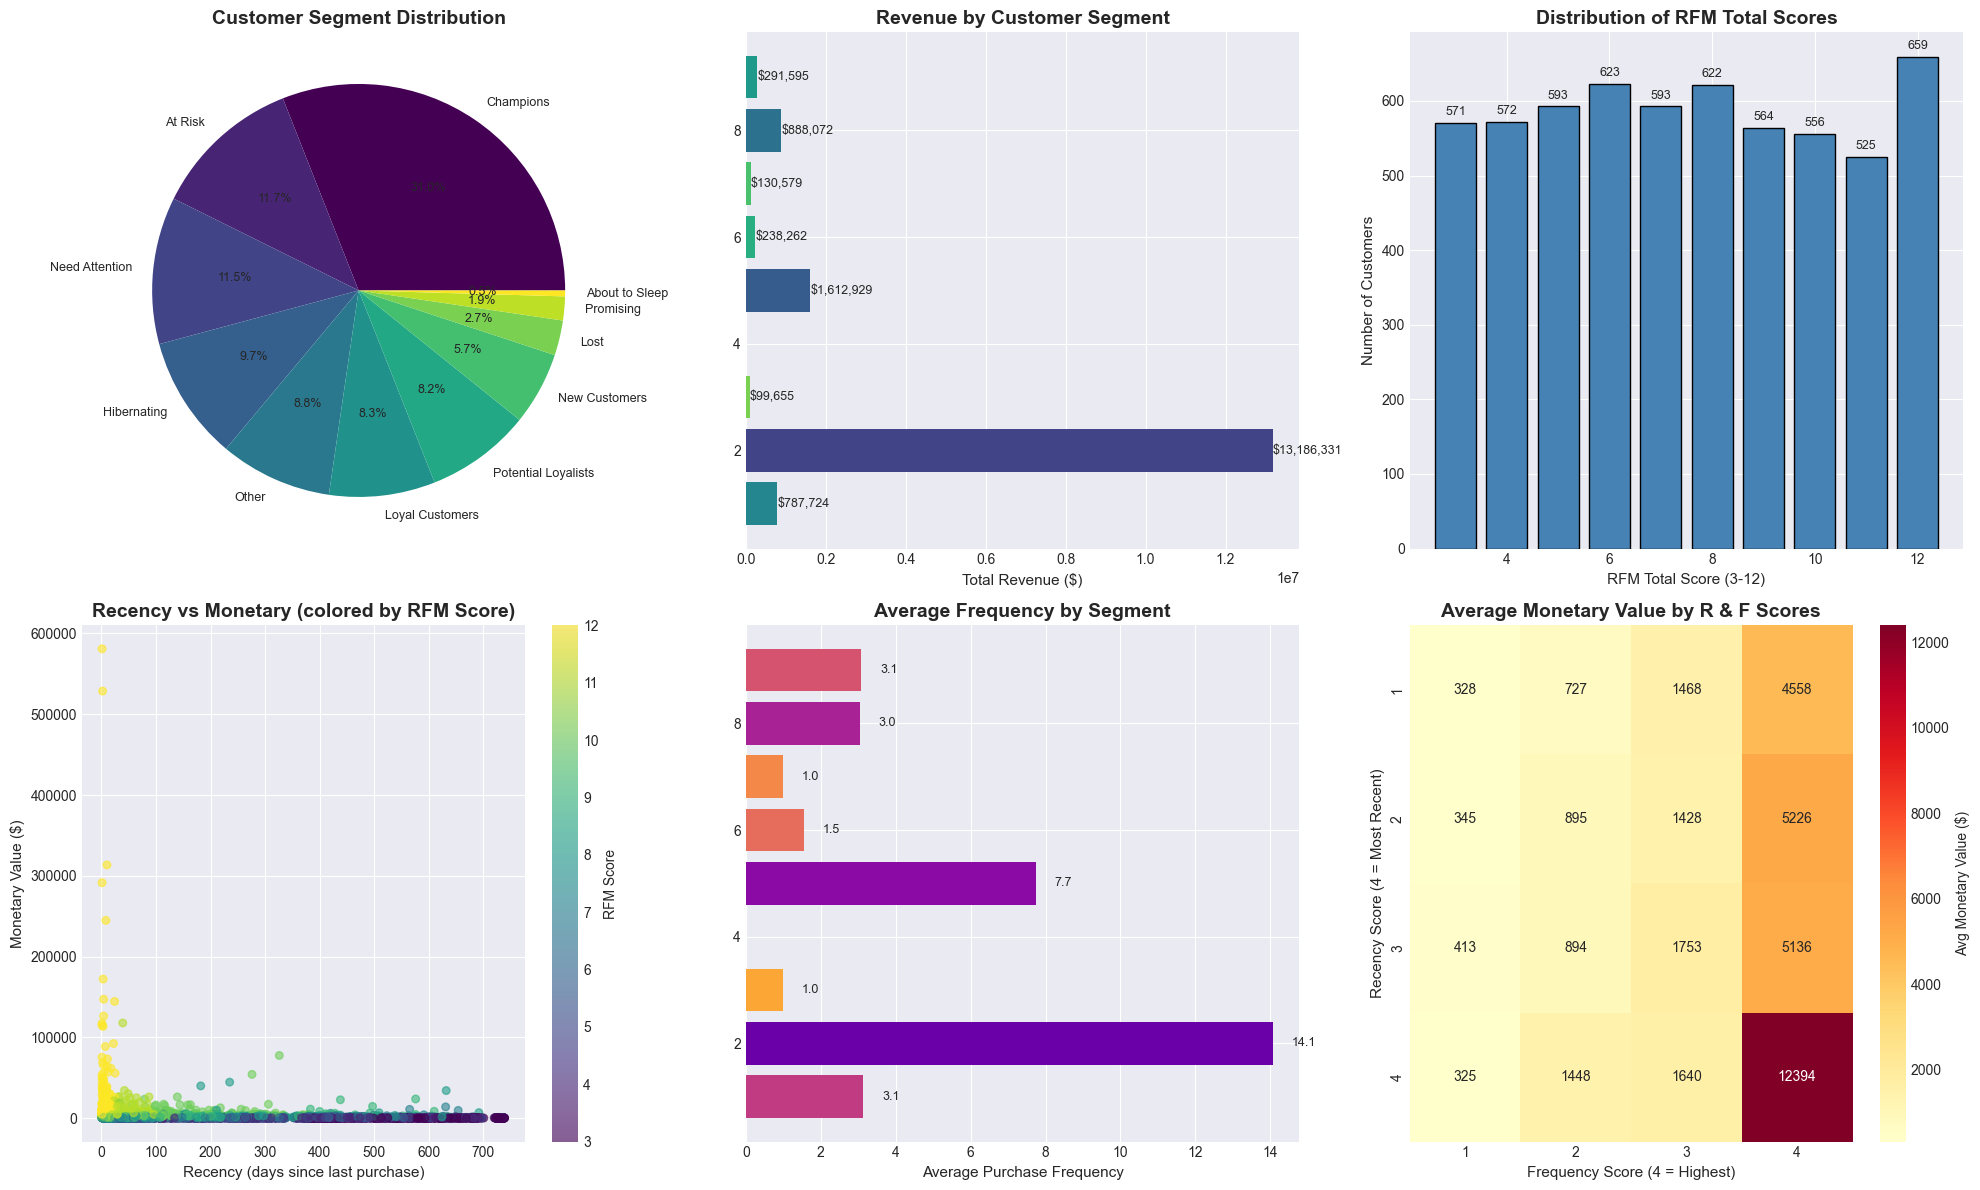

In [19]:
# Set up the figure
fig = plt.figure(figsize=(20, 12))

# 7.1 Segment Distribution Pie Chart
ax1 = fig.add_subplot(2, 3, 1)
colors = plt.cm.viridis(np.linspace(0, 1, len(segment_counts)))
wedges, texts, autotexts = ax1.pie(segment_counts.values, 
                                     labels=segment_counts.index,
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     textprops={'fontsize': 9})
ax1.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')

# 7.2 Revenue by Segment Bar Chart
ax2 = fig.add_subplot(2, 3, 2)
top_segments = segment_kpis.head(8)
bars = ax2.barh(top_segments.index, top_segments['total_revenue'], color=plt.cm.viridis(np.linspace(0.2, 0.8, len(top_segments))))
ax2.set_xlabel('Total Revenue ($)', fontsize=11)
ax2.set_title('Revenue by Customer Segment', fontsize=14, fontweight='bold')
# Add value labels
for i, (bar, value) in enumerate(zip(bars, top_segments['total_revenue'])):
    ax2.text(value, bar.get_y() + bar.get_height()/2, f'${value:,.0f}', 
             va='center', ha='left', fontsize=9)

# 7.3 RFM Score Distribution
ax3 = fig.add_subplot(2, 3, 3)
rfm_score_counts = rfm['rfm_total'].value_counts().sort_index()
ax3.bar(rfm_score_counts.index, rfm_score_counts.values, color='steelblue', edgecolor='black')
ax3.set_xlabel('RFM Total Score (3-12)', fontsize=11)
ax3.set_ylabel('Number of Customers', fontsize=11)
ax3.set_title('Distribution of RFM Total Scores', fontsize=14, fontweight='bold')
for i, (score, count) in enumerate(rfm_score_counts.items()):
    ax3.text(score, count + 10, str(count), ha='center', fontsize=9)

# 7.4 Recency vs Monetary Scatter Plot
ax4 = fig.add_subplot(2, 3, 4)
# Sample for better visualization (if too many points)
sample_size = min(5000, len(rfm))
rfm_sample = rfm.sample(n=sample_size, random_state=42)
scatter = ax4.scatter(rfm_sample['recency'], rfm_sample['monetary'], 
                      c=rfm_sample['rfm_total'], cmap='viridis', alpha=0.6, s=30)
ax4.set_xlabel('Recency (days since last purchase)', fontsize=11)
ax4.set_ylabel('Monetary Value ($)', fontsize=11)
ax4.set_title('Recency vs Monetary (colored by RFM Score)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax4, label='RFM Score')

# 7.5 Average Frequency by Segment
ax5 = fig.add_subplot(2, 3, 5)
top_segments_plot = segment_kpis.head(8)
bars = ax5.barh(top_segments_plot.index, top_segments_plot['avg_frequency'], 
                color=plt.cm.plasma(np.linspace(0.2, 0.8, len(top_segments_plot))))
ax5.set_xlabel('Average Purchase Frequency', fontsize=11)
ax5.set_title('Average Frequency by Segment', fontsize=14, fontweight='bold')
for i, (bar, value) in enumerate(zip(bars, top_segments_plot['avg_frequency'])):
    ax5.text(value + 0.5, bar.get_y() + bar.get_height()/2, f'{value:.1f}', 
             va='center', ha='left', fontsize=9)

# 7.6 Heatmap of RFM Segments (FIXED - removed dollar sign from format)
ax6 = fig.add_subplot(2, 3, 6)
# Create a pivot table for R and F scores
heatmap_data = pd.crosstab(rfm['r_score'], rfm['f_score'], values=rfm['monetary'], aggfunc='mean')
# Use a simple numeric format without currency symbol for the heatmap annotations
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax6, 
            cbar_kws={'label': 'Avg Monetary Value ($)'})
ax6.set_xlabel('Frequency Score (4 = Highest)', fontsize=11)
ax6.set_ylabel('Recency Score (4 = Most Recent)', fontsize=11)
ax6.set_title('Average Monetary Value by R & F Scores', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/rfm_analysis_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
print("✅ Visualizations saved to '../reports/rfm_analysis_visualization.png'")


✅ Visualizations saved to '../reports/rfm_analysis_visualization.png'


### =========================
### 8. TOP CUSTOMERS BY SEGMENT
### =========================

In [21]:
# Get top customers per high-value segment
high_value_segments = ['Champions', 'Loyal Customers', 'Cannot Lose Them']


In [22]:
top_customers = rfm[rfm['customer_segment'].isin(high_value_segments)].nlargest(20, 'monetary')[['customer_id', 'customer_segment', 'recency', 'frequency', 'monetary', 'rfm_total']]
print("\n🏆 Top 20 High-Value Customers:")
print(top_customers)


🏆 Top 20 High-Value Customers:
      customer_id customer_segment  recency  frequency   monetary  rfm_total
5692        18102        Champions        1        145  580987.04         12
2277        14646        Champions        2        151  528602.52         12
1789        14156        Champions       10        156  313437.62         12
2538        14911        Champions        1        398  291420.81         12
5050        17450        Champions        8         51  244784.25         12
1331        13694        Champions        4        143  195640.69         12
5109        17511        Champions        3         60  172132.87         12
4295        16684        Champions        4         55  147142.77         12
68          12415        Champions       24         28  144458.37         12
2685        15061        Champions        4        127  126389.02         12
3647        16029        Champions       39        107  117763.62         11
5540        17949        Champions        1 

### =========================
### 9. MARKETING RECOMMENDATIONS
### =========================

In [23]:
recommendations = {
    'Champions': [
        '🎯 Exclusive VIP loyalty program',
        '🎯 Early access to new products',
        '🎯 Personalized thank you notes with discounts',
        '🎯 Referral program with premium rewards'
    ],
    'Loyal Customers': [
        '🎯 Cross-selling and upselling campaigns',
        '🎯 Product bundles based on purchase history',
        '🎯 Loyalty points program',
        '🎯 Birthday/anniversary special offers'
    ],
    'Potential Loyalists': [
        '🎯 Engagement campaigns to increase purchase frequency',
        '🎯 First-time buyer follow-up discounts',
        '🎯 Product recommendation emails',
        '🎯 Abandoned cart recovery offers'
    ],
    'New Customers': [
        '🎯 Welcome series emails with discount codes',
        '🎯 Onboarding guides and product tutorials',
        '🎯 Second purchase incentive',
        '🎯 Customer satisfaction survey'
    ],
    'Need Attention': [
        '🎯 Re-engagement email campaigns',
        '🎯 Limited-time flash sales',
        '🎯 Free shipping threshold reminders',
        '🎯 Product categories they showed interest in'
    ],
    'About to Sleep': [
        '⚠️ Reactivation campaigns with significant discounts',
        '⚠️ "We miss you" emails',
        '⚠️ Win-back offers (15-20% off)',
        '⚠️ New arrivals in their favorite categories'
    ],
    'At Risk': [
        '⚠️ High-value win-back coupons',
        '⚠️ Personalized recommendations from past purchases',
        '⚠️ Customer feedback survey',
        '⚠️ Last chance reminders'
    ],
    'Cannot Lose Them': [
        '🔴 Priority customer service line',
        '🔴 Personalized outreach from account manager',
        '🔴 Exclusive early access to sales',
        '🔴 Premium loyalty tier invitation'
    ],
    'Hibernating': [
        '🔴 Major discount win-back campaigns (25-30% off)',
        '🔴 "We have new products you might like" emails',
        '🔴 Retargeting ads across platforms',
        '🔴 Customer win-back survey'
    ],
    'Lost': [
        '🔴 Final attempt win-back campaign',
        '🔴 Exit survey for feedback',
        '🔴 Seasonal mega-sale notifications',
        '🔴 Alternative channel reach (social media)'
    ]
}

In [24]:
print("\n📋 MARKETING RECOMMENDATIONS BY SEGMENT")
print("=" * 60)

for segment, recs in recommendations.items():
    count = segment_counts.get(segment, 0)
    if count > 0:
        print(f"\n✨ {segment} ({count} customers - {segment_percentages.get(segment, 0):.1f}%)")
        for rec in recs:
            print(f"   {rec}")



📋 MARKETING RECOMMENDATIONS BY SEGMENT

✨ Champions (1821 customers - 31.0%)
   🎯 Exclusive VIP loyalty program
   🎯 Early access to new products
   🎯 Personalized thank you notes with discounts
   🎯 Referral program with premium rewards

✨ Loyal Customers (488 customers - 8.3%)
   🎯 Cross-selling and upselling campaigns
   🎯 Product bundles based on purchase history
   🎯 Loyalty points program
   🎯 Birthday/anniversary special offers

✨ Potential Loyalists (483 customers - 8.2%)
   🎯 Engagement campaigns to increase purchase frequency
   🎯 First-time buyer follow-up discounts
   🎯 Product recommendation emails
   🎯 Abandoned cart recovery offers

✨ New Customers (336 customers - 5.7%)
   🎯 Welcome series emails with discount codes
   🎯 Onboarding guides and product tutorials
   🎯 Second purchase incentive
   🎯 Customer satisfaction survey

✨ Need Attention (677 customers - 11.5%)
   🎯 Re-engagement email campaigns
   🎯 Limited-time flash sales
   🎯 Free shipping threshold reminders
 

### =========================
### 10. EXPORT FOR POWER BI
### =========================

In [25]:
# Merge RFM scores back to original transaction data
df_with_rfm = df.merge(rfm[['customer_id', 'recency', 'frequency', 'monetary', 
                            'r_score', 'f_score', 'm_score', 'rfm_score', 
                            'rfm_total', 'customer_segment']], 
                        on='customer_id', how='left')

print(f"\n📁 Data with RFM attributes shape: {df_with_rfm.shape}")



📁 Data with RFM attributes shape: (779425, 25)


In [26]:
# Create segment-level aggregated data for dashboard
segment_summary_export = segment_kpis.copy()
segment_summary_export.columns = ['customer_segment', 'customer_count', 'avg_recency', 
                                   'avg_frequency', 'avg_monetary', 'total_revenue', 
                                   'revenue_percentage']

# Create monthly segment trends
df_with_rfm['year_month'] = pd.to_datetime(df_with_rfm['year_month'])
monthly_segment_revenue = df_with_rfm.groupby(['year_month', 'customer_segment'])['total_price'].sum().reset_index()
monthly_segment_revenue.columns = ['year_month', 'customer_segment', 'revenue']
monthly_segment_revenue['year_month'] = monthly_segment_revenue['year_month'].dt.strftime('%Y-%m')

# Create RFM score distribution table
rfm_score_distribution = rfm.groupby(['r_score', 'f_score', 'm_score']).size().reset_index(name='customer_count')
rfm_score_distribution['rfm_combination'] = rfm_score_distribution['r_score'].astype(str) + rfm_score_distribution['f_score'].astype(str) + rfm_score_distribution['m_score'].astype(str)


In [27]:
# Save all exports for Power BI
df_with_rfm.to_csv('../data/processed/transactions_with_rfm.csv', index=False)
segment_summary_export.to_csv('../data/processed/rfm_segment_summary.csv', index=False)
monthly_segment_revenue.to_csv('../data/processed/monthly_segment_revenue.csv', index=False)
rfm_score_distribution.to_csv('../data/processed/rfm_score_distribution.csv', index=False)
rfm.to_csv('../data/processed/rfm_customer_scores.csv', index=False)


In [28]:
print("\n✅ Exported for Power BI:")
print("   - transactions_with_rfm.csv (full transaction data with RFM attributes)")
print("   - rfm_segment_summary.csv (segment-level KPIs)")
print("   - monthly_segment_revenue.csv (time-based segment performance)")
print("   - rfm_score_distribution.csv (RFM score combination distribution)")
print("   - rfm_customer_scores.csv (customer-level RFM scores)")



✅ Exported for Power BI:
   - transactions_with_rfm.csv (full transaction data with RFM attributes)
   - rfm_segment_summary.csv (segment-level KPIs)
   - monthly_segment_revenue.csv (time-based segment performance)
   - rfm_score_distribution.csv (RFM score combination distribution)
   - rfm_customer_scores.csv (customer-level RFM scores)


### =========================
### 11. ACTIONABLE INSIGHTS SUMMARY
### =========================

In [29]:
print(segment_kpis.columns)

Index(['customer_segment', 'customer_count', 'avg_recency', 'avg_frequency',
       'avg_monetary', 'total_revenue', 'revenue_percentage'],
      dtype='str')


In [30]:
def get_segment_metric(segment_name, metric_column):
    segment_row = segment_kpis[segment_kpis['customer_segment'] == segment_name]
    if not segment_row.empty:
        return segment_row[metric_column].iloc[0]
    return 0

In [31]:
# Use the helper function
champions_revenue = get_segment_metric('Champions', 'total_revenue')
champions_pct = get_segment_metric('Champions', 'revenue_percentage')
at_risk_revenue = get_segment_metric('At Risk', 'total_revenue')
cannot_lose_revenue = get_segment_metric('Cannot Lose Them', 'total_revenue')

champions_count = segment_counts.get('Champions', 0)
at_risk_count = segment_counts.get('At Risk', 0)
cannot_lose_count = segment_counts.get('Cannot Lose Them', 0)

total_at_risk_revenue = at_risk_revenue + cannot_lose_revenue
total_at_risk_count = at_risk_count + cannot_lose_count

print("\n" + "="*70)
print("🎯 KEY BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*70)

print(f"""
📌 INSIGHT 1: Customer Concentration
   • {champions_count} Champions generate ${champions_revenue:,.2f} in revenue
   • This represents {champions_pct:.1f}% of total revenue
   • ACTION: Implement VIP program to retain these high-value customers

📌 INSIGHT 2: At-Risk Customers
   • {total_at_risk_count} customers are "At Risk" or "Cannot Lose Them"
   • These customers previously spent ${total_at_risk_revenue:,.2f}
   • ACTION: Launch immediate win-back campaign with personalized offers

📌 INSIGHT 3: Segment Migration Strategy
   • "Potential Loyalists" can be upgraded to "Loyal Customers" with +2 purchases
   • "New Customers" have high churn risk after first purchase
   • ACTION: Create automated workflow for second purchase incentive

📌 INSIGHT 4: Marketing ROI Focus
   • Focus 60% of marketing budget on Champions, Loyal, and At Risk segments
   • Use low-cost email automation for New and Promising segments
   • Test win-back campaigns on Hibernating before writing off as Lost

📌 INSIGHT 5: Dashboard KPIs to Monitor
   • Monthly segment migration rates
   • RFM score distribution changes over time
   • Revenue concentration by segment
   • Customer lifetime value by acquisition channel
""")


🎯 KEY BUSINESS INSIGHTS & RECOMMENDATIONS

📌 INSIGHT 1: Customer Concentration
   • 1821 Champions generate $13,186,331.03 in revenue
   • This represents 75.9% of total revenue
   • ACTION: Implement VIP program to retain these high-value customers

📌 INSIGHT 2: At-Risk Customers
   • 687 customers are "At Risk" or "Cannot Lose Them"
   • These customers previously spent $787,723.78
   • ACTION: Launch immediate win-back campaign with personalized offers

📌 INSIGHT 3: Segment Migration Strategy
   • "Potential Loyalists" can be upgraded to "Loyal Customers" with +2 purchases
   • "New Customers" have high churn risk after first purchase
   • ACTION: Create automated workflow for second purchase incentive

📌 INSIGHT 4: Marketing ROI Focus
   • Focus 60% of marketing budget on Champions, Loyal, and At Risk segments
   • Use low-cost email automation for New and Promising segments
   • Test win-back campaigns on Hibernating before writing off as Lost

📌 INSIGHT 5: Dashboard KPIs to Moni

In [32]:
# Save insights to text file
with open('../reports/rfm_insights_summary.txt', 'w') as f:
    f.write("RFM ANALYSIS INSIGHTS SUMMARY\n")
    f.write("="*50 + "\n\n")
    f.write(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d')}\n")
    f.write(f"Total Customers Analyzed: {len(rfm):,}\n")
    f.write(f"Total Revenue: ${df['total_price'].sum():,.2f}\n\n")
    f.write("Segment Distribution:\n")
    for segment, count in segment_counts.items():
        f.write(f"  {segment}: {count} customers ({segment_percentages[segment]}%)\n")
    f.write("\n" + "="*50 + "\n")
    f.write("Key Recommendations:\n")
    f.write("- Retain Champions with VIP program\n")
    f.write("- Recover At Risk customers with win-back offers\n")
    f.write("- Convert New Customers with second purchase incentives\n")
    f.write("- Monitor segment migration monthly\n")


In [33]:
print("\n✅ Insights saved to '../reports/rfm_insights_summary.txt'")
print("\n🎉 RFM Analysis Complete!")


✅ Insights saved to '../reports/rfm_insights_summary.txt'

🎉 RFM Analysis Complete!
